copykat: r_env2 \
seurat: r-base

copykat https://github.com/navinlabcode/copykat \
benchmarking + yml https://github.com/colomemaria/benchmark_scrnaseq_cnv_callers \
scevan https://github.com/AntonioDeFalco/SCEVAN

In [1]:
library(Seurat)
raw <- Read10X(data.dir = "/home/opiskunova/THESIS/run_cellranger_count/ak/run_count_ak/outs/filtered_feature_bc_matrix")

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode



In [2]:
raw <- CreateSeuratObject(counts = raw, project = "copycat.test", min.cells = 0, min.features = 0)
exp.rawdata <- as.matrix(raw@assays$RNA@counts)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.2 GiB”


In [3]:
write.table(exp.rawdata, file="exp.rawdata_ak.txt", sep="\t", quote = FALSE, row.names = TRUE)

In [1]:
exp_data <- read.delim(
  file = "./copykat_ak/exp.rawdata_ak.txt",
  row.names = 1,
  check.names = FALSE
)

In [2]:
length(exp_data)

[1] 11193

In [3]:
#new
library(copykat)
copykat.test <- copykat(rawmat=exp_data, id.type="S", ngene.chr=5, win.size=25, KS.cut=0.1, sam.name="test", distance="euclidean", norm.cell.names="",output.seg="FLASE", plot.genes="TRUE", genome="hg20",n.cores=1)

[1] "running copykat v1.1.0"
[1] "step1: read and filter data ..."
[1] "38606 genes, 11193 cells in raw data"
[1] "filtered out 2232 cells with less than min.gene.per.cell; remaining 8973 cells"
[1] "6441 genes past LOW.DR filtering"
[1] "WARNING: low data quality; assigned LOW.DR to UP.DR..."
[1] "step 2: annotations gene coordinates ..."
[1] "start annotation ..."
[1] "step 3: smoothing data with dlm ..."
[1] "step 4: measuring baselines ..."
number of iterations= 169 
number of iterations= 1333 
number of iterations= 545 
number of iterations= 931 
number of iterations= 363 
number of iterations= 1064 
[1] "low confidence in classification"
[1] "cell: 1"
number of iterations= 257 
[1] "cell: 2"
WARNING! NOT CONVERGENT! 
number of iterations= 500 
[1] "cell: 3"
number of iterations= 418 
[1] "cell: 4"
WARNING! NOT CONVERGENT! 
number of iterations= 500 
[1] "cell: 5"
number of iterations= 336 
[1] "cell: 6"
number of iterations= 319 
[1] "cell: 7"
WARNING! NOT CONVERGENT! 
number of 

In [7]:
# #new
# library(copykat)
# copykat.test <- copykat(rawmat=exp.rawdata, id.type="S", ngene.chr=5, win.size=25, KS.cut=0.1, sam.name="test", distance="euclidean", norm.cell.names="",output.seg="FLASE", plot.genes="TRUE", genome="hg20",n.cores=1)

[1] "running copykat v1.1.0"
[1] "step1: read and filter data ..."
[1] "33694 genes, 302 cells in raw data"
[1] "12156 genes past LOW.DR filtering"
[1] "step 2: annotations gene coordinates ..."
[1] "start annotation ..."
[1] "step 3: smoothing data with dlm ..."
[1] "step 4: measuring baselines ..."
number of iterations= 315 
number of iterations= 679 
number of iterations= 214 
number of iterations= 823 
number of iterations= 431 
number of iterations= 823 
[1] "step 5: segmentation..."
[1] "step 6: convert to genomic bins..."
[1] "step 7: adjust baseline ..."
[1] "step 8: final prediction ..."
[1] "step 9: saving results..."
[1] "step 10: ploting heatmap ..."
Time difference of 2.759996 mins


In [4]:
#new
pred.test <- data.frame(copykat.test$prediction)
pred.test <- pred.test[which(pred.test$copykat.pred %in% c("aneuploid","diploid")),]  ##keep defined cells
CNA.test <- data.frame(copykat.test$CNAmat)

In [5]:
# length 5979
head(pred.test) 

,cell.names,copykat.pred
,<chr>,<chr>
AAACCCAAGCTTGTGT.1,AAACCCAAGCTTGTGT-1,diploid
AAACCCATCGTACACA.1,AAACCCATCGTACACA-1,aneuploid
AAACGAAAGGCGACAT.1,AAACGAAAGGCGACAT-1,diploid
AAACGAACAGTAGATA.1,AAACGAACAGTAGATA-1,aneuploid
AAACGAAGTCCGGTGT.1,AAACGAAGTCCGGTGT-1,diploid
AAACGCTAGAAATTGC.1,AAACGCTAGAAATTGC-1,aneuploid


In [7]:
pred.test

,cell.names,copykat.pred
,<chr>,<chr>
AAACCCAAGCTTGTGT.1,AAACCCAAGCTTGTGT-1,diploid
AAACCCATCGTACACA.1,AAACCCATCGTACACA-1,aneuploid
AAACGAAAGGCGACAT.1,AAACGAAAGGCGACAT-1,diploid
AAACGAACAGTAGATA.1,AAACGAACAGTAGATA-1,aneuploid
AAACGAAGTCCGGTGT.1,AAACGAAGTCCGGTGT-1,diploid
AAACGCTAGAAATTGC.1,AAACGCTAGAAATTGC-1,aneuploid
AAACGCTCAACTCGTA.1,AAACGCTCAACTCGTA-1,diploid
AAACGCTCAATAGGAT.1,AAACGCTCAATAGGAT-1,diploid
AAACGCTCACAGTCAT.1,AAACGCTCACAGTCAT-1,diploid


In [9]:
write.csv(pred.test, file = "pred_test_ak2.csv", row.names = TRUE)

In [8]:
head(CNA.test[ , 1:5])

,chrom,chrompos,abspos,AAACCCAAGCTTGTGT.1,AAACCCATCGTACACA.1
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,1042457,1042457,0.07511081,0.01840184
2,1,1265484,1265484,0.07511081,0.01840184
3,1,1519859,1519859,0.07511081,0.01840184
4,1,1826619,1826619,0.07511081,0.01840184
5,1,2058465,2058465,0.07511081,0.01840184
6,1,2280372,2280372,0.07511081,0.01840184


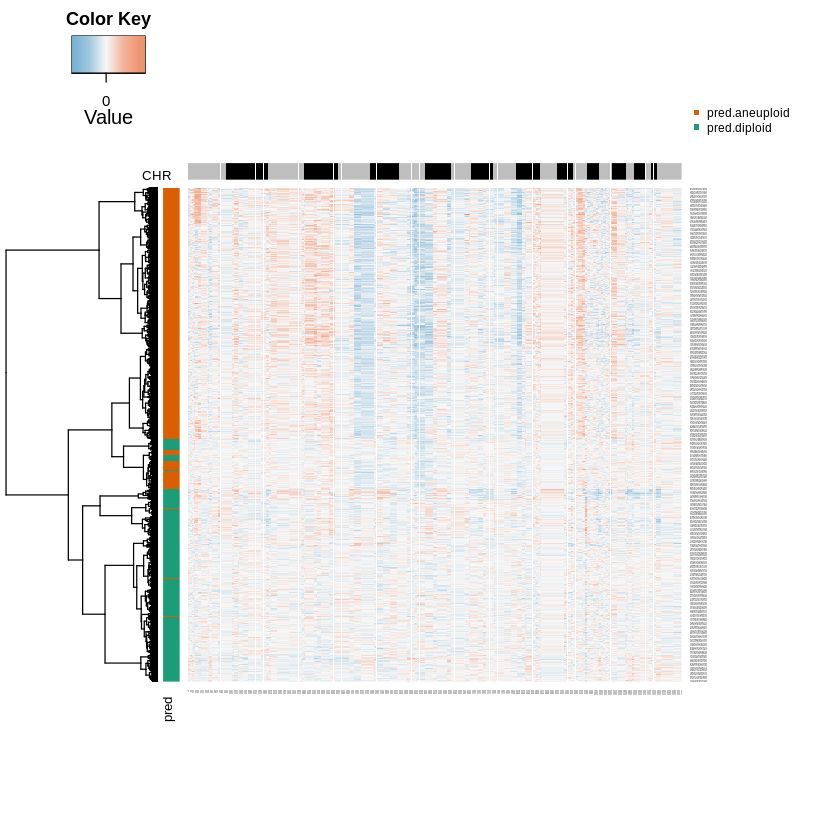

In [10]:
  my_palette <- colorRampPalette(rev(RColorBrewer::brewer.pal(n = 3, name = "RdBu")))(n = 999)

  chr <- as.numeric(CNA.test$chrom) %% 2+1
  rbPal1 <- colorRampPalette(c('black','grey'))
  CHR <- rbPal1(2)[as.numeric(chr)]
  chr1 <- cbind(CHR,CHR)

  rbPal5 <- colorRampPalette(RColorBrewer::brewer.pal(n = 8, name = "Dark2")[2:1])
  com.preN <- pred.test$copykat.pred
  pred <- rbPal5(2)[as.numeric(factor(com.preN))]

  cells <- rbind(pred,pred)
  col_breaks = c(seq(-1,-0.4,length=50),seq(-0.4,-0.2,length=150),seq(-0.2,0.2,length=600),seq(0.2,0.4,length=150),seq(0.4, 1,length=50))

heatmap.3(t(CNA.test[,4:ncol(CNA.test)]),dendrogram="r", distfun = function(x) parallelDist::parDist(x,threads =4, method = "euclidean"), hclustfun = function(x) hclust(x, method="ward.D2"),
            ColSideColors=chr1,RowSideColors=cells,Colv=NA, Rowv=TRUE,
            notecol="black",col=my_palette,breaks=col_breaks, key=TRUE,
            keysize=1, density.info="none", trace="none",
            cexRow=0.1,cexCol=0.1,cex.main=1,cex.lab=0.1,
            symm=F,symkey=F,symbreaks=T,cex=1, cex.main=4, margins=c(10,10))

  legend("topright", paste("pred.",names(table(com.preN)),sep=""), pch=15,col=RColorBrewer::brewer.pal(n = 8, name = "Dark2")[2:1], cex=0.6, bty="n")


In [11]:
tumor.cells <- pred.test$cell.names[which(pred.test$copykat.pred=="aneuploid")]
tumor.mat <- CNA.test[, which(colnames(CNA.test) %in% tumor.cells)]
hcc <- hclust(parallelDist::parDist(t(tumor.mat),threads =4, method = "euclidean"), method = "ward.D2")
hc.umap <- cutree(hcc,2)

rbPal6 <- colorRampPalette(RColorBrewer::brewer.pal(n = 8, name = "Dark2")[3:4])
subpop <- rbPal6(2)[as.numeric(factor(hc.umap))]
cells <- rbind(subpop,subpop)

heatmap.3(t(tumor.mat),dendrogram="r", distfun = function(x) parallelDist::parDist(x,threads =4, method = "euclidean"), hclustfun = function(x) hclust(x, method="ward.D2"),
            ColSideColors=chr1,RowSideColors=cells,Colv=NA, Rowv=TRUE,
            notecol="black",col=my_palette,breaks=col_breaks, key=TRUE,
            keysize=1, density.info="none", trace="none",
            cexRow=0.1,cexCol=0.1,cex.main=1,cex.lab=0.1,
            symm=F,symkey=F,symbreaks=T,cex=1, cex.main=4, margins=c(10,10))

  legend("topright", c("c1","c2"), pch=15,col=RColorBrewer::brewer.pal(n = 8, name = "Dark2")[3:4], cex=0.9, bty='n')


ERROR: Error in hclust(parallelDist::parDist(t(tumor.mat), threads = 4, method = "euclidean"), : must have n >= 2 objects to cluster
